<center><h1 style="font-size:3em;">Universidad Nacional de Loja</h1></center><center><h3>Trabajo realizado por Roy Gordillo</h3></center>

## Tarea 1: Configuración Inicial

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")


Entorno configurado correctamente


## Tarea 2: Variable Aleatoria Discreta (Dado)

In [ ]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))



Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


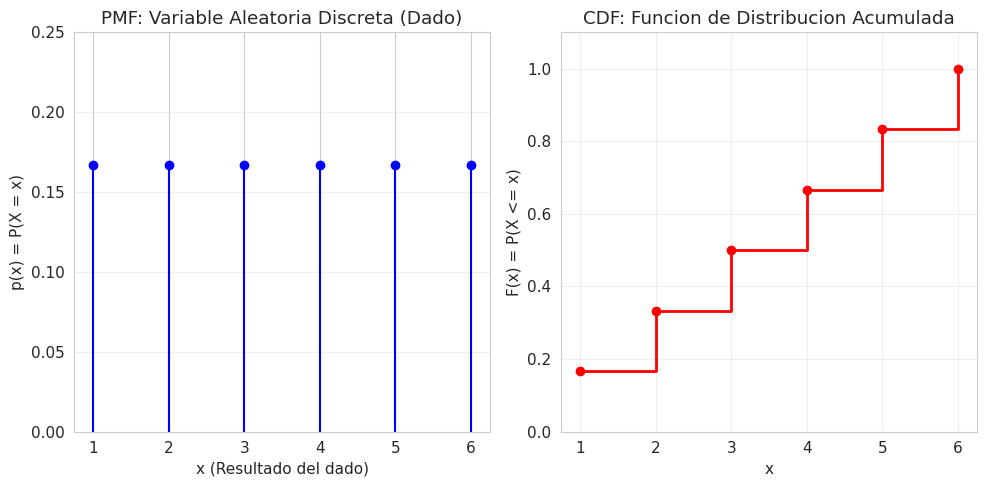

In [ ]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")


P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


## Tarea 3: Variable Aleatoria Continua (Normal)

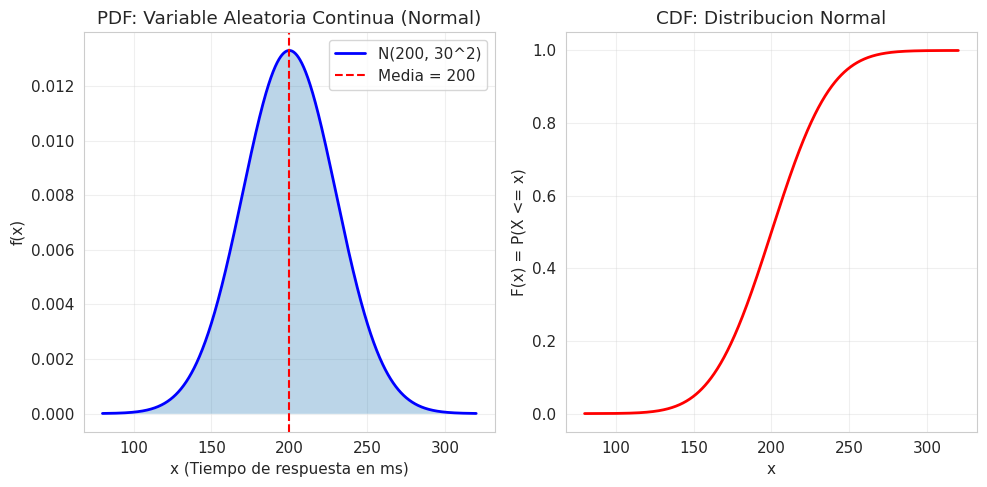

In [ ]:
# Parametros de la distribucion normal
mu = 200  # media
sigma = 30  # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")

# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")


P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


## Tarea 4: Comparación de Variables Aleatorias

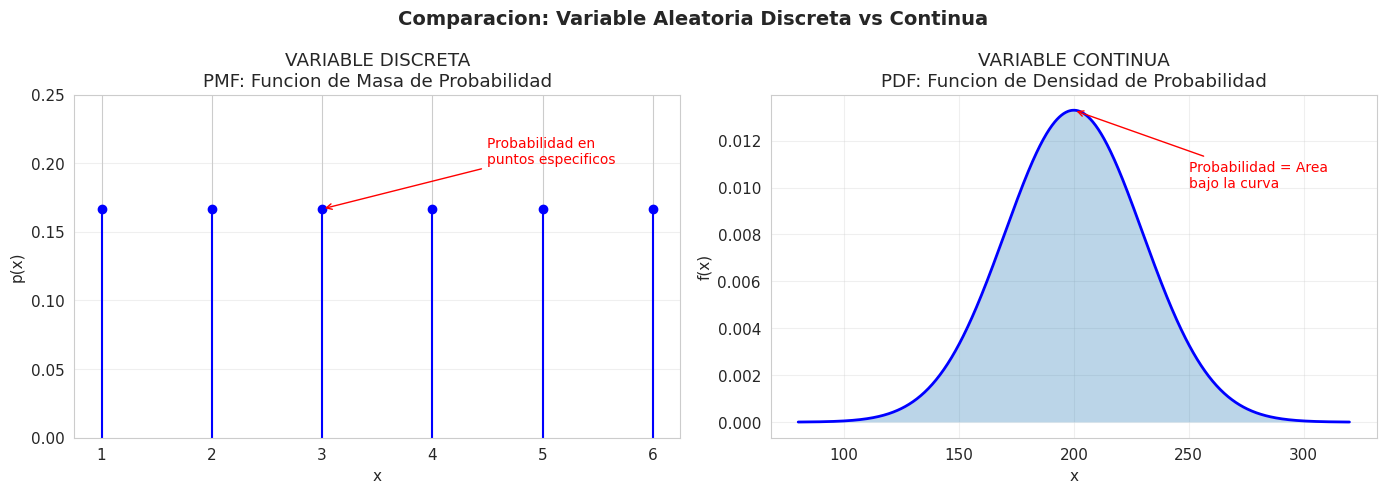

In [ ]:
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Tarea 5: Ejemplos de Variables en la UNL

In [ ]:
import pandas as pd

# 1. Configuración para separar y organizar las columnas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.unicode.east_asian_width', True) # Ayuda con el alineamiento

# 2. Plantilla con encabezados en MAYÚSCULAS
variables_unl = [
    {
        'NOMBRE': 'Ingreso de estudiantes/hora',
        'UBICACION': 'Biblioteca Central',
        'TIPO': 'Discreta',S
        'VALORES POSIBLES': '0, 1, 2, 3...',
        'DISTRIBUCION ESPERADA': 'Poisson'
    },
    {
        'NOMBRE': 'Tiempo de espera en fila',
        'UBICACION': 'Cafetería Central',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '0 a 15 minutos',
        'DISTRIBUCION ESPERADA': 'Exponencial'
    },
    {
        'NOMBRE': 'Equipos operativos',
        'UBICACION': 'Lab. Computación',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0 a 30 equipos',
        'DISTRIBUCION ESPERADA': 'Binomial'
    },
    {
        'NOMBRE': 'Vehículos estacionados',
        'UBICACION': 'Estacionamiento UNL',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0 a 50 vehículos',
        'DISTRIBUCION ESPERADA': 'Binomial'
    },
    {
        'NOMBRE': 'Estatura de estudiantes',
        'UBICACION': 'Aulas de clase',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '1.50m a 1.95m',
        'DISTRIBUCION ESPERADA': 'Normal'
    }
]

df = pd.DataFrame(variables_unl)

# 3. El truco para el espacio: Col_space añade pixeles/caracteres de separación
# 'justify' centra los encabezados y 'col_space' separa las columnas
print(df.to_string(index=False, justify='center', col_space=25))

           NOMBRE                   UBICACION                    TIPO                VALORES POSIBLES       DISTRIBUCION ESPERADA  
Ingreso de estudiantes/hora     Biblioteca Central             Discreta                 0, 1, 2, 3...                Poisson       
   Tiempo de espera en fila      Cafetería Central             Continua                0 a 15 minutos            Exponencial       
         Equipos operativos       Lab. Computación             Discreta                0 a 30 equipos               Binomial       
     Vehículos estacionados    Estacionamiento UNL             Discreta              0 a 50 vehículos               Binomial       
    Estatura de estudiantes         Aulas de clase             Continua                 1.50m a 1.95m                 Normal       


Parámetro p (probabilidad de éxito): 0.5
Valores posibles de X: [0, 1]
PMF p(x) para X=0 (fracaso) y X=1 (éxito): [0.5, 0.5]
Suma de probabilidades: 1.00



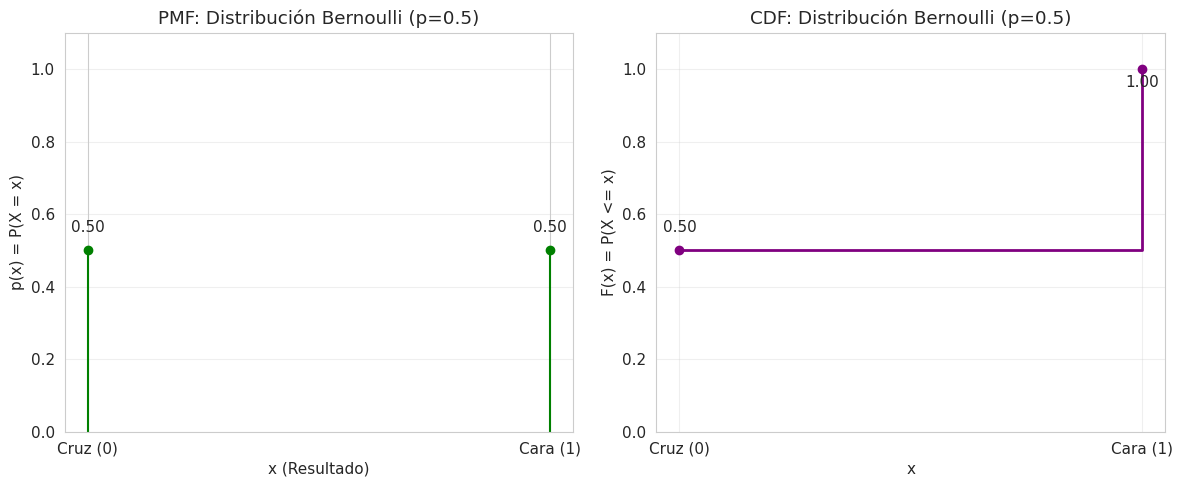


--- Cálculos de Probabilidades e Interpretación ---
P(X = 1) = 0.5000
Interpretación: La probabilidad de obtener una 'cara' en un lanzamiento es del 50%.
P(X = 0) = 0.5000
Interpretación: La probabilidad de obtener una 'cruz' en un lanzamiento es del 50%.
P(X <= 0.5) = 0.5000
Interpretación: La probabilidad de que el resultado sea 'cruz' (0) o menos es del 50%.


In [ ]:
# Opcion A: Distribución Bernoulli (lanzamiento de moneda)

# --- 1. Definición de la distribución Bernoulli ---
# Un experimento Bernoulli tiene dos resultados posibles: éxito (1) o fracaso (0).
# p = probabilidad de éxito.

p = 0.5  # Probabilidad de obtener 'cara' en un lanzamiento de moneda justa
x_bernoulli = [0, 1] # 0: cruz, 1: cara

# PMF para Bernoulli: P(X=x) = p^x * (1-p)^(1-x)
pmf_bernoulli = [1 - p, p]

print(f"Parámetro p (probabilidad de éxito): {p}")
print(f"Valores posibles de X: {x_bernoulli}")
print(f"PMF p(x) para X=0 (fracaso) y X=1 (éxito): {pmf_bernoulli}")
print(f"Suma de probabilidades: {np.sum(pmf_bernoulli):.2f}\n")

# --- 2. Generación de gráficas PMF y CDF ---
plt.figure(figsize=(12, 5))

# PMF (Probability Mass Function)
plt.subplot(1, 2, 1)
plt.stem(x_bernoulli, pmf_bernoulli, basefmt=" ", linefmt='g-', markerfmt='go')
plt.xlabel('x (Resultado)')
plt.ylabel('p(x) = P(X = x)')
plt.title(f'PMF: Distribución Bernoulli (p={p})')
plt.xticks(x_bernoulli, ['Cruz (0)', 'Cara (1)'])
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.text(x_bernoulli[0], pmf_bernoulli[0] + 0.05, f'{pmf_bernoulli[0]:.2f}', ha='center')
plt.text(x_bernoulli[1], pmf_bernoulli[1] + 0.05, f'{pmf_bernoulli[1]:.2f}', ha='center')

# CDF (Cumulative Distribution Function)
cdf_bernoulli = np.cumsum(pmf_bernoulli)
plt.subplot(1, 2, 2)
plt.step(x_bernoulli, cdf_bernoulli, where='post', color='purple', linewidth=2)
plt.scatter(x_bernoulli, cdf_bernoulli, color='purple', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title(f'CDF: Distribución Bernoulli (p={p})')
plt.xticks(x_bernoulli, ['Cruz (0)', 'Cara (1)'])
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.text(x_bernoulli[0], cdf_bernoulli[0] + 0.05, f'{cdf_bernoulli[0]:.2f}', ha='center')
plt.text(x_bernoulli[1], cdf_bernoulli[1] - 0.05, f'{cdf_bernoulli[1]:.2f}', ha='center')

plt.tight_layout()
plt.show()

# --- 3. Cálculo e interpretación de probabilidades específicas ---
print("\n--- Cálculos de Probabilidades e Interpretación ---")

# a) Probabilidad de obtener cara (X = 1)
prob_cara = pmf_bernoulli[1]
print(f"P(X = 1) = {prob_cara:.4f}")
print("Interpretación: La probabilidad de obtener una 'cara' en un lanzamiento es del 50%.")

# b) Probabilidad de obtener cruz (X = 0)
prob_cruz = pmf_bernoulli[0]
print(f"P(X = 0) = {prob_cruz:.4f}")
print("Interpretación: La probabilidad de obtener una 'cruz' en un lanzamiento es del 50%.")

# c) Probabilidad de obtener un resultado menor o igual a 0.5 (usando CDF)
# Esto significa P(X <= 0) ya que 0 es el único valor entero <= 0.5
prob_menor_igual_0_5 = cdf_bernoulli[0]
print(f"P(X <= 0.5) = {prob_menor_igual_0_5:.4f}")
print("Interpretación: La probabilidad de que el resultado sea 'cruz' (0) o menos es del 50%.")
